# Modelado Fenomenológico de Secado Continuo al Vacío
## Transición de Cinética Empírica a Termodinámica de Estado

Este cuaderno establece el modelo matemático determinista para un horno de cinta transportadora operando a bajo vacío. A diferencia de los modelos basados en ajustes estadísticos (como Arrhenius), este modelo utiliza los principios de conservación de materia y energía.

### La Transformación Espacial ($z$) vs Temporal ($t$)
En un horno continuo, el producto viaja sobre una cinta a una velocidad constante $v$. Por lo tanto, el tiempo de residencia depende de la posición $z$ en el horno:
$$z = v \cdot t \implies dt = \frac{dz}{v}$$

Sustituyendo el diferencial de tiempo en nuestros balances fenomenológicos, obtenemos el **perfil espacial en estado estacionario**:
1. **Balance de Materia:** $\frac{dX}{dz} = \frac{1}{v} \cdot f_X(X, T)$
2. **Balance de Energía:** $\frac{dT}{dz} = \frac{1}{v} \cdot f_T(X, T)$

In [7]:
import numpy as np
from scipy.integrate import odeint, solve_ivp
import matplotlib.pyplot as plt
import warnings

### 1. El Motor Termodinámico (Ecuación de Antoine)
Encapsulamos las propiedades del agua. Este módulo será consultado miles de veces por el solver numérico para determinar la **fuerza impulsora** en cada centímetro de la cinta transportadora.

In [8]:
# Importamos la instancia 'Agua' directamente desde nuestro motor termodinámico
from termodinamica import Agua

# Verificamos que el módulo se conectó correctamente
P_prueba = Agua.presion_saturacion(25)
print(f"Módulo conectado exitosamente. Presión de vapor a 25°C: {P_prueba:.2f} mmHg")

Módulo conectado exitosamente. Presión de vapor a 25°C: 23.69 mmHg


### 2. Ecuaciones Diferenciales Ordinarias (EDOs) con Perfil Zonal
En un secador continuo de múltiples niveles (7 cintas del SUNGDZ-130, 91 metros totales), la temperatura de la fuente de calor no es constante. Se aplica una función a tramos $T_{bandeja}(z)$ dividida en 4 secciones de calefacción y 1 de refrigeración para reducir el aporte térmico a medida que la biomasa se seca, evitando la degradación térmica de compuestos sensibles.

In [9]:
def derivadas_horno_multinivel(z, y, P_horno_mbar, perfil_temp_func, m_seco, A_contacto, U, K_masa, v_cinta_mh):
    X, T = y
    
    v_cinta_ms = v_cinta_mh / 3600.0  
    P_horno_mmHg = P_horno_mbar * 0.750062
    P_vapor_ambiente = P_horno_mmHg * 0.10 
    
    # 1. Fuerza impulsora termodinámica
    P_sat_producto = Agua.presion_saturacion(T)
    
    # ==========================================
    # BALANCE DE MATERIA
    # ==========================================
    if P_sat_producto > P_vapor_ambiente and X > 0.05:
        dX_dt = - (K_masa * A_contacto / m_seco) * (P_sat_producto - P_vapor_ambiente)
    else:
        dX_dt = 0.0 

    if X <= 0.05: dX_dt = max(0.0, dX_dt)

    m_evap_rate = -dX_dt * m_seco 

    # ==========================================
    # BALANCE DE ENERGÍA ZONAL
    # ==========================================
    # Consultamos la temperatura de la bandeja en la posición 'z' actual
    T_bandeja_z = perfil_temp_func(z)
    
    # El calor entrante ahora depende del nivel en el que se encuentre la biomasa
    Q_in = U * A_contacto * (T_bandeja_z - T) 
    
    delta_H_vap = 2501000 - 2370 * T 
    Q_evap = m_evap_rate * delta_H_vap 
    
    Cp_biomasa = 1600.0 
    Cp_agua = 4186.0
    Cap_Calorifica_Total = (m_seco * Cp_biomasa) + (m_seco * X * Cp_agua)
    
    dT_dt = (Q_in - Q_evap) / Cap_Calorifica_Total
    
    # Transformación al dominio espacial (dz)
    dX_dz = dX_dt / v_cinta_ms
    dT_dz = dT_dt / v_cinta_ms
    
    return [dX_dz, dT_dz]

### 3. Configuración del Equipo (SUNGDZ-130) y Resolución Numérica
Definimos los 7 niveles del secador SUNGDZ-130 (13 metros cada uno para un total de 91m), divididos termodinámicamente en 4 secciones de calefacción y 1 de refrigeración, y programamos el perfil escalonado de temperaturas.

In [10]:
# Parámetros Geométricos del Horno SUNGDZ-130 (7 Niveles / Cintas)
L_total = 91.0       # Longitud total (7 cintas x 13 m = 91 metros)
L_nivel = L_total/7  # 13 metros por nivel

def perfil_temperaturas_7_niveles(z):
    """Retorna la temperatura de consigna de las placas según el nivel (posición z)
    para el Gemelo Digital SUNGDZ-130 (7 cintas transportadoras).
    Dividido en 4 secciones de calefacción y 1 de refrigeración:
    - Sección 1 (Calefacción 1): Cintas 1 y 2 (65.0 °C)
    - Sección 2 (Calefacción 2): Cintas 3 y 4 (55.0 °C)
    - Sección 3 (Calefacción 3): Cinta 5 (45.0 °C)
    - Sección 4 (Calefacción 4): Cinta 6 (35.0 °C)
    - Sección 5 (Refrigeración): Cinta 7 (25.0 °C)
    """
    if 0 <= z < L_nivel * 1:
        return 65.0  # Cinta 1 (Sección Calefacción 1)
    elif L_nivel * 1 <= z < L_nivel * 2:
        return 65.0  # Cinta 2 (Sección Calefacción 1)
    elif L_nivel * 2 <= z < L_nivel * 3:
        return 55.0  # Cinta 3 (Sección Calefacción 2)
    elif L_nivel * 3 <= z < L_nivel * 4:
        return 55.0  # Cinta 4 (Sección Calefacción 2)
    elif L_nivel * 4 <= z < L_nivel * 5:
        return 45.0  # Cinta 5 (Sección Calefacción 3)
    elif L_nivel * 5 <= z < L_nivel * 6:
        return 35.0  # Cinta 6 (Sección Calefacción 4)
    else:
        return 25.0  # Cinta 7 (Sección Refrigeración)

# Parámetros Operativos
v_cinta = 3.5        # Velocidad de la cinta (m/h)
P_horno = 15.0       # Presión de vacío (mbar)
m_seco = 5.0         
A_contacto = 1.5     
U_calor = 12.0       
K_masa = 2.0e-4      

y0 = [1.915, 10.0]     # [Humedad inicial bs, Temperatura inicial °C]

params = (P_horno, perfil_temperaturas_7_niveles, m_seco, A_contacto, U_calor, K_masa, v_cinta)

sol = solve_ivp(
    fun=derivadas_horno_multinivel, 
    t_span=(0, L_total), 
    y0=y0, 
    args=params, 
    method='Radau', 
    dense_output=True,
    max_step=0.2 # Pasos de 20 cm para capturar bien los saltos entre niveles
)

z_metros = sol.t
X_out = sol.y[0]
T_out = sol.y[1]
Humedad_BH = (X_out / (1 + X_out)) * 100

# Extraemos el perfil de la bandeja para graficarlo como una curva escalonada
T_placas_perfil = [perfil_temperaturas_7_niveles(pos) for pos in z_metros]

### 4. Visualización del Perfil Termodinámico
Graficamos la evolución espacial de la temperatura y la humedad a lo largo de los metros del horno de secado.

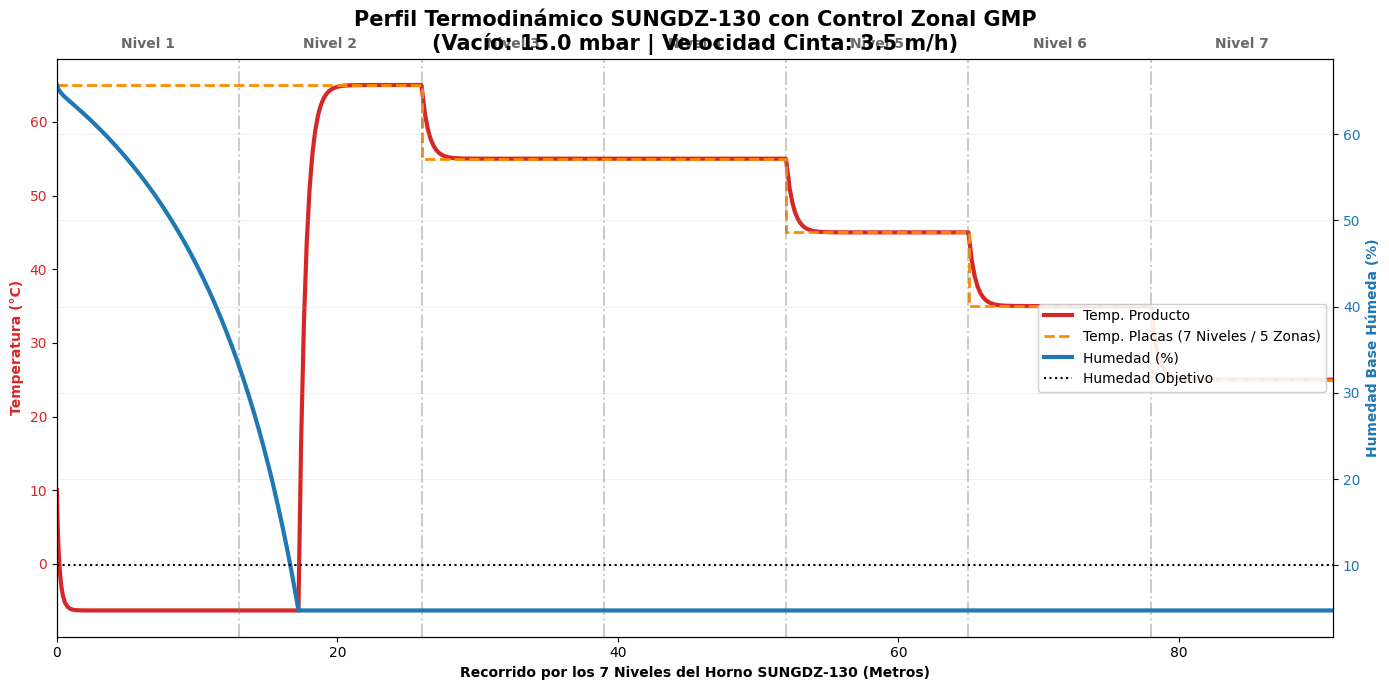

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 7))

color_T = 'tab:red'
ax1.set_xlabel('Recorrido por los 7 Niveles del Horno SUNGDZ-130 (Metros)', fontweight='bold')
ax1.set_ylabel('Temperatura (°C)', color=color_T, fontweight='bold')

# Graficamos el producto y la placa
l1 = ax1.plot(z_metros, T_out, color=color_T, linewidth=3, label='Temp. Producto')
l2 = ax1.plot(z_metros, T_placas_perfil, color='darkorange', linestyle='--', linewidth=2, drawstyle='steps-post', label='Temp. Placas (7 Niveles / 5 Zonas)')

ax1.tick_params(axis='y', labelcolor=color_T)

# Separadores visuales para los 7 niveles
for i in range(1, 7):
    ax1.axvline(x=L_nivel*i, color='gray', linestyle='-.', alpha=0.4)
    ax1.text(L_nivel*i - 6.5, 70, f'Nivel {i}', ha='center', color='dimgray', fontweight='bold')
ax1.text(L_total - 6.5, 70, 'Nivel 7', ha='center', color='dimgray', fontweight='bold')

ax2 = ax1.twinx()
color_H = 'tab:blue'
ax2.set_ylabel('Humedad Base Húmeda (%)', color=color_H, fontweight='bold')
l3 = ax2.plot(z_metros, Humedad_BH, color=color_H, linewidth=3, label='Humedad (%)')
l4 = ax2.axhline(10.0, color='black', linestyle=':', label='Humedad Objetivo')
ax2.tick_params(axis='y', labelcolor=color_H)

lineas = l1 + l2 + l3 + [l4]
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='center right', framealpha=0.9)

plt.title(f'Perfil Termodinámico SUNGDZ-130 con Control Zonal GMP\n(Vacío: {P_horno} mbar | Velocidad Cinta: {v_cinta} m/h)', fontweight='bold', fontsize=15)
plt.xlim(0, L_total)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 4. Automatización y Control: Optimización de la Velocidad de Cinta
En la operación industrial, la velocidad de la cinta transportadora ($v$) es la variable manipulada principal del PLC. Para garantizar una calidad GMP (ej. exactamente 5% de humedad final), planteamos un problema de búsqueda de raíces unidimensional.

Definimos una función objetivo $f(v)$ que ejecuta la simulación completa y calcula el error residual:
$$f(v) = X_{final\_calculado}(v) - X_{objetivo}$$

Utilizando el método de Brent (`scipy.optimize.root_scalar`), el algoritmo iterará inteligentemente diferentes velocidades hasta encontrar la raíz de la ecuación ($f(v) = 0$), dándonos la velocidad óptima sin intervención humana.

In [12]:
from scipy.optimize import root_scalar

# 1. Definir la Humedad Objetivo
Humedad_BH_objetivo = 7.0 # Queremos un 7% de humedad en base húmeda
# Convertimos Base Húmeda a Base Seca para el modelo matemático (X = bh / (100.0 - bh))
X_objetivo_bs = Humedad_BH_objetivo / (100.0 - Humedad_BH_objetivo)

# 2. Crear la Función Objetivo ("Wrapper")
def error_humedad_final(v_prueba):
    """
    Ejecuta el horno con una velocidad 'v_prueba'.
    Retorna la diferencia entre la humedad final obtenida y la deseada.
    """
    # Empaquetamos los parámetros usando la velocidad de prueba
    params_prueba = (P_horno, perfil_temperaturas_7_niveles, m_seco, A_contacto, U_calor, K_masa, v_prueba)
    
    # Resolvemos la EDO sin generar output denso (más rápido)
    sol_prueba = solve_ivp(
        fun=derivadas_horno_multinivel, 
        t_span=(0, L_total), 
        y0=y0, 
        args=params_prueba, 
        method='Radau'
    )
    
    # Extraemos el último valor de humedad (al final de los 91 metros)
    X_final_obtenido = sol_prueba.y[0][-1]
    
    # El error que el algoritmo intentará hacer cero
    return X_final_obtenido - X_objetivo_bs

# 3. Ejecutar el Optimizador (Método de Brent)
print("Iniciando optimización del Gemelo Digital SUNGDZ-130...")

# El parámetro 'bracket' le da al algoritmo un rango donde buscar [v_minima, v_maxima].
# Asumimos que la cinta se moverá entre 0.5 m/h (muy lento) y 50.0 m/h (muy rápido).
resultado_opt = root_scalar(
    error_humedad_final, 
    bracket=[0.5, 50.0], 
    method='brentq',
    xtol=1e-4 # Tolerancia del error
)

if resultado_opt.converged:
    v_optima = resultado_opt.root
    tiempo_residencia = L_total / v_optima
    print("✅ ¡Optimización Exitosa!")
    print("-" * 40)
    print(f"Velocidad óptima de la cinta: {v_optima:.2f} m/h")
    print(f"Tiempo de residencia total:   {tiempo_residencia:.1f} horas")
else:
    print("❌ El optimizador no pudo encontrar una solución en el rango especificado.")


Iniciando optimización del Gemelo Digital SUNGDZ-130...
✅ ¡Optimización Exitosa!
----------------------------------------
Velocidad óptima de la cinta: 15.11 m/h
Tiempo de residencia total:   6.0 horas


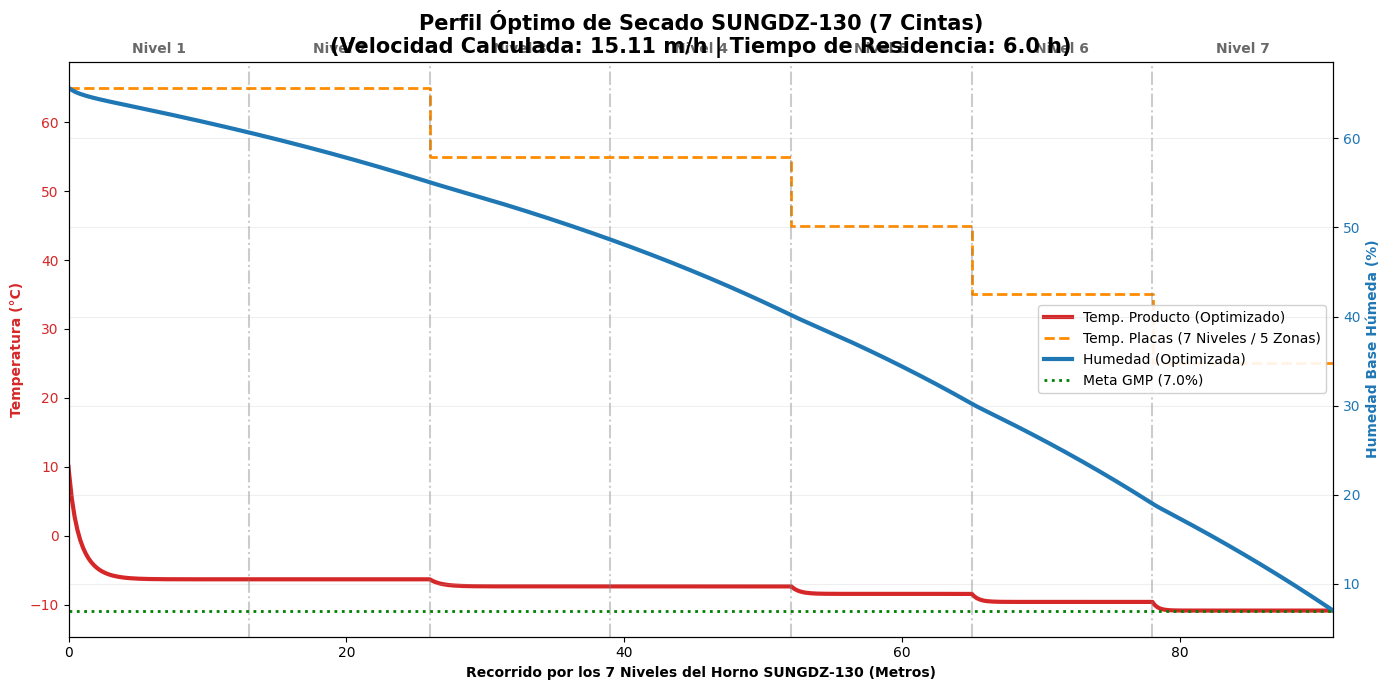

In [13]:
# Re-ejecutamos la simulación con la velocidad óptima encontrada para extraer los vectores
params_finales = (P_horno, perfil_temperaturas_7_niveles, m_seco, A_contacto, U_calor, K_masa, v_optima)
sol_opt = solve_ivp(
    fun=derivadas_horno_multinivel, 
    t_span=(0, L_total), 
    y0=y0, 
    args=params_finales, 
    method='Radau', 
    dense_output=True,
    max_step=0.2
)

z_opt = sol_opt.t
X_opt = sol_opt.y[0]
T_opt = sol_opt.y[1]
Humedad_BH_opt = (X_opt / (1 + X_opt)) * 100
T_placas_opt = [perfil_temperaturas_7_niveles(pos) for pos in z_opt]

# Visualización del Perfil Óptimo
fig, ax1 = plt.subplots(figsize=(14, 7))

color_T = 'tab:red'
ax1.set_xlabel('Recorrido por los 7 Niveles del Horno SUNGDZ-130 (Metros)', fontweight='bold')
ax1.set_ylabel('Temperatura (°C)', color=color_T, fontweight='bold')
l1 = ax1.plot(z_opt, T_opt, color=color_T, linewidth=3, label='Temp. Producto (Optimizado)')
l2 = ax1.plot(z_opt, T_placas_opt, color='darkorange', linestyle='--', linewidth=2, drawstyle='steps-post', label='Temp. Placas (7 Niveles / 5 Zonas)')
ax1.tick_params(axis='y', labelcolor=color_T)

# Separadores visuales para los 7 niveles
for i in range(1, 7):
    ax1.axvline(x=L_nivel*i, color='gray', linestyle='-.', alpha=0.4)
    ax1.text(L_nivel*i - 6.5, 70, f'Nivel {i}', ha='center', color='dimgray', fontweight='bold')
ax1.text(L_total - 6.5, 70, 'Nivel 7', ha='center', color='dimgray', fontweight='bold')

ax2 = ax1.twinx()
color_H = 'tab:blue'
ax2.set_ylabel('Humedad Base Húmeda (%)', color=color_H, fontweight='bold')
l3 = ax2.plot(z_opt, Humedad_BH_opt, color=color_H, linewidth=3, label='Humedad (Optimizada)')
l4 = ax2.axhline(Humedad_BH_objetivo, color='green', linestyle=':', linewidth=2, label=f'Meta GMP ({Humedad_BH_objetivo}%)')
ax2.tick_params(axis='y', labelcolor=color_H)

lineas = l1 + l2 + l3 + [l4]
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='center right', framealpha=0.9)

plt.title(f'Perfil Óptimo de Secado SUNGDZ-130 (7 Cintas)\n(Velocidad Calculada: {v_optima:.2f} m/h | Tiempo de Residencia: {tiempo_residencia:.1f} h)', fontweight='bold', fontsize=15)
plt.xlim(0, L_total)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 5. Coeficientes Dinámicos: Encogimiento y Resistencia Térmica (Matriz Biológica)
En la biomasa real, los parámetros de transporte no son constantes. A medida que el material entra en el período post-crítico de secado:
* **Encogimiento Volumétrico (Shrinkage):** El área de contacto $A(X)$ disminuye lineal o polinómicamente con la pérdida de humedad.
* **Aislamiento Térmico:** El coeficiente global de transferencia de calor $U(X)$ cae abruptamente debido a que el agua (buen conductor) en los poros es reemplazada por aire/vacío (excelente aislante).

Se proponen relaciones lineales dependientes de la humedad relativa a la inicial ($X/X_0$):
$$U(X) = U_{seco} + (U_{inicial} - U_{seco}) \cdot \frac{X}{X_0}$$
$$A(X) = A_{seco} + (A_{inicial} - A_{seco}) \cdot \frac{X}{X_0}$$

In [14]:
def derivadas_horno_dinamico(z, y, P_horno_mbar, perfil_temp_func, m_seco, params_dinamicos, v_cinta_mh):
    """
    Versión Avanzada con Coeficientes Dependientes de la Humedad (X)
    """
    X, T = y
    
    # Desempaquetar los límites de los coeficientes dinámicos
    U_ini, U_sec, A_ini, A_sec, K_masa, X_0 = params_dinamicos
    
    v_cinta_ms = v_cinta_mh / 3600.0  
    P_horno_mmHg = P_horno_mbar * 0.750062
    P_vapor_ambiente = P_horno_mmHg * 0.10 
    
    # 1. Fuerza impulsora termodinámica
    P_sat_producto = Agua.presion_saturacion(T)
    
    # ==========================================
    # ACTUALIZACIÓN DE COEFICIENTES (Shrinkage y Conductividad)
    # ==========================================
    # Fracción de humedad restante (de 1.0 al inicio, tendiendo a 0 al final)
    fraccion_X = max(0.0, min(1.0, X / X_0))
    
    U_actual = U_sec + (U_ini - U_sec) * fraccion_X
    A_actual = A_sec + (A_ini - A_sec) * fraccion_X
    
    # ==========================================
    # BALANCE DE MATERIA
    # ==========================================
    if P_sat_producto > P_vapor_ambiente and X > 0.05:
        # Notar que ahora usamos A_actual
        dX_dt = - (K_masa * A_actual / m_seco) * (P_sat_producto - P_vapor_ambiente)
    else:
        dX_dt = 0.0 

    if X <= 0.05: dX_dt = max(0.0, dX_dt)

    m_evap_rate = -dX_dt * m_seco 

    # ==========================================
    # BALANCE DE ENERGÍA ZONAL
    # ==========================================
    T_bandeja_z = perfil_temp_func(z)
    
    # El calor entrante está severamente castigado al final del secado por la caída de U_actual y A_actual
    Q_in = U_actual * A_actual * (T_bandeja_z - T) 
    
    delta_H_vap = 2501000 - 2370 * T 
    Q_evap = m_evap_rate * delta_H_vap 
    
    Cp_biomasa = 1600.0 
    Cp_agua = 4186.0
    Cap_Calorifica_Total = (m_seco * Cp_biomasa) + (m_seco * X * Cp_agua)
    
    dT_dt = (Q_in - Q_evap) / Cap_Calorifica_Total
    
    # Transformación al dominio espacial
    dX_dz = dX_dt / v_cinta_ms
    dT_dz = dT_dt / v_cinta_ms
    
    return [dX_dz, dT_dz]

In [15]:
# Condiciones Iniciales reales
X_0_real = 1.915      # Humedad base seca (aprox 65.7% bh) de inflorescencias de exterior
T_0_real = 10.0       # Cosecha matutina
y0_real = [X_0_real, T_0_real]

# Definición de la caída de coeficientes por pérdida turgencia y secado
U_inicial = 12.0      # Material húmedo, excelente contacto y conducción
U_seco    = 8.0       # Material seco, poroso, altamente aislante al vacío
A_inicial = 1.5       # m2 de área expuesta por lote diferencial (hinchado)
A_seco    = 0.7       # Contracción volumétrica severa de la flor seca

# Empaquetamos los parámetros dinámicos
params_dinamicos = (U_inicial, U_seco, A_inicial, A_seco, K_masa, X_0_real)

# Nueva función objetivo para el optimizador
def error_humedad_dinamico(v_prueba):
    params = (P_horno, perfil_temperaturas_7_niveles, m_seco, params_dinamicos, v_prueba)
    sol = solve_ivp(
        fun=derivadas_horno_dinamico, 
        t_span=(0, L_total), 
        y0=y0_real, 
        args=params, 
        method='Radau'
    )
    return sol.y[0][-1] - X_objetivo_bs

print("Iniciando optimización con modelo de coeficientes dinámicos SUNGDZ-130...")

# Buscamos la nueva velocidad óptima
resultado_dinamico = root_scalar(
    error_humedad_dinamico, 
    bracket=[0.1, 50.0],  # Ampliamos el rango de búsqueda hacia abajo por si necesita ir más lento
    method='brentq',
    xtol=1e-4
)

if resultado_dinamico.converged:
    v_optima_dinamica = resultado_dinamico.root
    t_residencia_dinamico = L_total / v_optima_dinamica
    print("✅ Optimización de Matriz Dinámica Exitosa!")
    print("-" * 50)
    print(f"Velocidad óptima corregida: {v_optima_dinamica:.2f} m/h")
    print(f"Nuevo tiempo de residencia:   {t_residencia_dinamico:.1f} horas")
else:
    print("❌ El optimizador no convergió.")


Iniciando optimización con modelo de coeficientes dinámicos SUNGDZ-130...
✅ Optimización de Matriz Dinámica Exitosa!
--------------------------------------------------
Velocidad óptima corregida: 8.83 m/h
Nuevo tiempo de residencia:   10.3 horas


<>:45: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:45: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\Electro\AppData\Local\Temp\ipykernel_6152\1609834503.py:45: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax.set_ylabel('Velocidad de Secado $R$ (kg$_{agua}$ / h $\cdot$ m$^2$)', fontweight='bold')


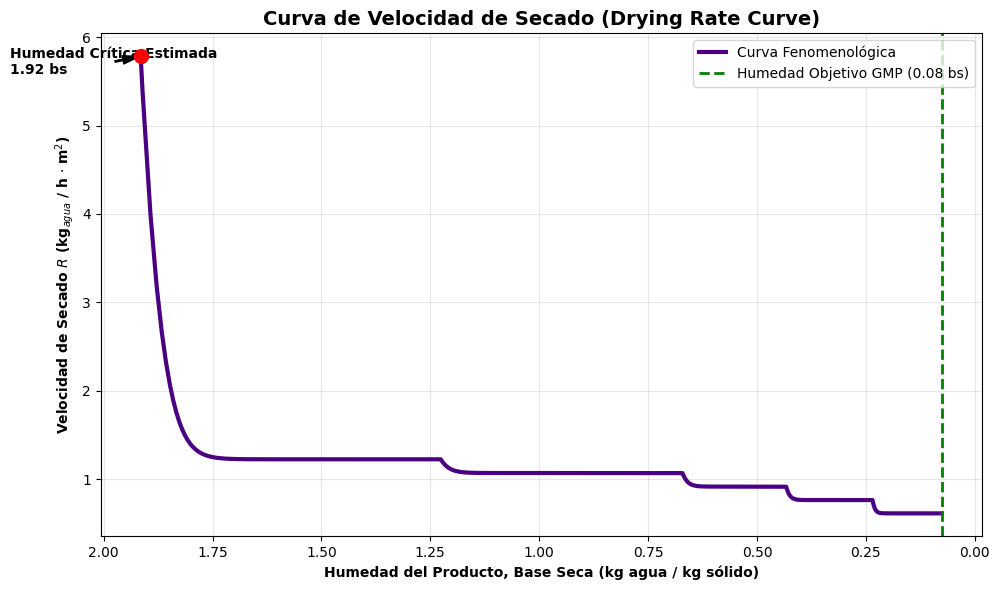

In [16]:
# =====================================================================
# CÁLCULO Y VISUALIZACIÓN DE LA CURVA DE VELOCIDAD DE SECADO
# =====================================================================

# 1. Reconstrucción de la tasa de evaporación en cada punto del horno
R_velocidad_secado = np.zeros_like(X_opt)
P_vapor_ambiente_mmHg = (P_horno * 0.750062) * 0.10

for i in range(len(X_opt)):
    X_actual = X_opt[i]
    T_actual = T_opt[i]
    
    # Recalcular la fuerza impulsora
    P_sat = Agua.presion_saturacion(T_actual)
    
    # Lógica de la EDO original
    if P_sat > P_vapor_ambiente_mmHg and X_actual > 0.05:
        # Reconstruir dX/dt (en 1/segundos)
        fraccion_X = max(0.0, min(1.0, X_actual / X_0_real))
        A_actual = A_seco + (A_inicial - A_seco) * fraccion_X
        
        dX_dt = - (K_masa * A_actual / m_seco) * (P_sat - P_vapor_ambiente_mmHg)
    else:
        dX_dt = 0.0
        A_actual = A_seco # Para evitar divisiones por cero en el flujo
        
    # Calcular R (Flujo de secado: kg agua evaporada / h * m2)
    m_evap_rate_kg_s = -dX_dt * m_seco
    R_flux_kg_h_m2 = (m_evap_rate_kg_s * 3600) / A_actual
    
    R_velocidad_secado[i] = R_flux_kg_h_m2

# 2. Gráfica Clásica de Velocidad de Secado (R vs X)
fig, ax = plt.subplots(figsize=(10, 6))

# Se grafica frente a la humedad Base Seca
ax.plot(X_opt, R_velocidad_secado, color='indigo', linewidth=3, label='Curva Fenomenológica')

# Por convención en ingeniería química, el eje X (humedad) se invierte
# para leerse de derecha (húmedo) a izquierda (seco) a medida que avanza el tiempo
ax.invert_xaxis()

ax.set_title('Curva de Velocidad de Secado (Drying Rate Curve)', fontweight='bold', fontsize=14)
ax.set_xlabel('Humedad del Producto, Base Seca (kg agua / kg sólido)', fontweight='bold')
ax.set_ylabel('Velocidad de Secado $R$ (kg$_{agua}$ / h $\cdot$ m$^2$)', fontweight='bold')

# Marcar el punto crítico estimado (donde la velocidad empieza a caer drásticamente)
punto_critico_idx = np.argmax(R_velocidad_secado)
X_critico = X_opt[punto_critico_idx]
R_max = R_velocidad_secado[punto_critico_idx]

ax.scatter([X_critico], [R_max], color='red', s=100, zorder=5)
ax.annotate(f'Humedad Crítica Estimada\n{X_critico:.2f} bs', 
            xy=(X_critico, R_max), xytext=(X_critico + 0.3, R_max - 0.2),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, fontweight='bold')

# Marcar la humedad final objetivo
ax.axvline(x=X_objetivo_bs, color='green', linestyle='--', linewidth=2, label=f'Humedad Objetivo GMP ({X_objetivo_bs:.2f} bs)')

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

--- ANÁLISIS DE ESTABILIDAD EN SALA DE DESCARGA ---
Humedad final del lote al salir del horno: 7.00 % (bh)
Condiciones de la Sala GMP: 17.0°C y 15.0% HR
Humedad de Equilibrio (EMC) del ambiente:  9.63 % (bh)
⚠️ ADVERTENCIA: La sala está muy húmeda. La flor reabsorberá agua (Adsorción).


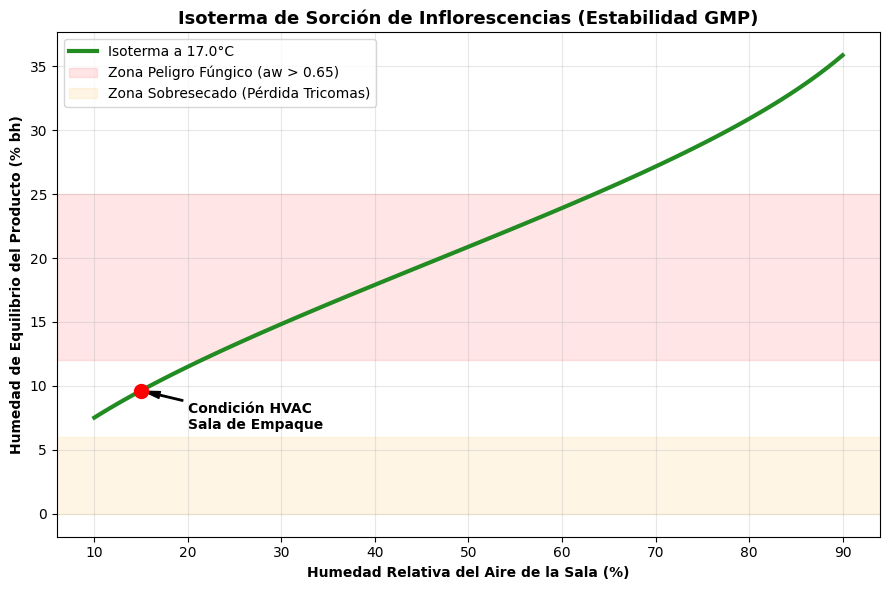

In [17]:
# =====================================================================
# MÓDULO HVAC: ESTABILIDAD POST-PROCESO E ISOTERMAS DE SORCIÓN
# =====================================================================

def isoterma_sorcion_cannabis(T_sala, HR_sala):
    """
    Calcula la Humedad de Equilibrio (EMC en base seca) usando un modelo 
    subrogado (Henderson Modificado) ajustado para biomasa vegetal resinosa.
    T_sala: Temperatura ambiente en °C
    HR_sala: Humedad Relativa del ambiente en porcentaje (0-100)
    """
    aw = HR_sala / 100.0
    # Restricción matemática para evitar ln(0) en saturación absoluta
    aw = max(0.01, min(aw, 0.99))
    
    # Constantes subrogadas estimadas para inflorescencias (requieren calibración de laboratorio)
    K1 = 5.5e-5
    K2 = 50.0
    K3 = 1.6
    
    EMC_bs = ( -np.log(1 - aw) / (K1 * (T_sala + K2)) ) ** (1 / K3)
    
    # El modelo devuelve el porcentaje, lo adaptamos a la escala de nuestro simulador (bs puro)
    return EMC_bs / 100.0

# 1. Definimos las condiciones de la sala blanca de descarga GMP
Temperatura_Sala = 17.0  # °C (Temperatura de confort y envasado)
Humedad_Relativa_Sala = 15.0  # % (HR objetivo del sistema de aire acondicionado)

# 2. Calculamos a qué humedad tenderá el producto si se deja en esa sala
EMC_sala = isoterma_sorcion_cannabis(Temperatura_Sala, Humedad_Relativa_Sala)
EMC_sala_bh = (EMC_sala / (1 + EMC_sala)) * 100

print("--- ANÁLISIS DE ESTABILIDAD EN SALA DE DESCARGA ---")
print(f"Humedad final del lote al salir del horno: {Humedad_BH_objetivo:.2f} % (bh)")
print(f"Condiciones de la Sala GMP: {Temperatura_Sala}°C y {Humedad_Relativa_Sala}% HR")
print(f"Humedad de Equilibrio (EMC) del ambiente:  {EMC_sala_bh:.2f} % (bh)")

if Humedad_BH_objetivo < EMC_sala_bh:
    print("⚠️ ADVERTENCIA: La sala está muy húmeda. La flor reabsorberá agua (Adsorción).")
elif Humedad_BH_objetivo > EMC_sala_bh:
    print("⚠️ ADVERTENCIA: La sala está muy seca. La flor perderá más humedad (Desorción).")
else:
    print("✅ ESTADO ÓPTIMO: Equilibrio termodinámico alcanzado. El producto es estable.")

# =====================================================================
# GRÁFICA DE LA ISOTERMA DE SORCIÓN A T_SALA CONSTANTE
# =====================================================================

vector_HR = np.linspace(10, 90, 100)
vector_EMC = [isoterma_sorcion_cannabis(Temperatura_Sala, hr) for hr in vector_HR]

# Convertimos todo a Base Húmeda para la gráfica comercial
vector_EMC_bh = [(emc / (1 + emc)) * 100 for emc in vector_EMC]

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(vector_HR, vector_EMC_bh, color='forestgreen', linewidth=3, label=f'Isoterma a {Temperatura_Sala}°C')

# Punto de operación de nuestra sala
ax.scatter([Humedad_Relativa_Sala], [EMC_sala_bh], color='red', s=100, zorder=5)
ax.annotate('Condición HVAC\nSala de Empaque', 
            xy=(Humedad_Relativa_Sala, EMC_sala_bh), xytext=(Humedad_Relativa_Sala + 5, EMC_sala_bh - 3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
            fontsize=10, fontweight='bold')

# Zonas de Peligro
ax.axhspan(12, 25, color='red', alpha=0.1, label='Zona Peligro Fúngico (aw > 0.65)')
ax.axhspan(0, 6, color='orange', alpha=0.1, label='Zona Sobresecado (Pérdida Tricomas)')

ax.set_title('Isoterma de Sorción de Inflorescencias (Estabilidad GMP)', fontweight='bold', fontsize=13)
ax.set_xlabel('Humedad Relativa del Aire de la Sala (%)', fontweight='bold')
ax.set_ylabel('Humedad de Equilibrio del Producto (% bh)', fontweight='bold')

ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()